In [17]:
import pandas as pd
import praw
import os
from dotenv import load_dotenv
import re
import spacy
import pickle
from tensorflow.keras.models import load_model
from wordcloud import WordCloud

import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

In [4]:
load_dotenv()

reddit = praw.Reddit(
    client_id=os.getenv("CLIENT_ID"),
    client_secret=os.getenv("TOKEN_REDDIT"),
    user_agent=('app.app')
)

# Test de connexion
print(reddit.read_only)

True


In [8]:
subreddit = reddit.subreddit('movies')

commentaires = []

# Récupère les 100 posts les plus récents
for post in subreddit.hot(limit=100):
    post.comments.replace_more(limit=0)  # charge tous les commentaires
    for comment in post.comments.list():
        commentaires.append({
            'post_title': post.title,
            'comment'   : comment.body,
            'score'     : comment.score,
            'date'      : comment.created_utc
        })


df_reddit = pd.DataFrame(commentaires)
print(f"{len(df_reddit):,} commentaires récupérés")
df_reddit.head()
df_reddit.to_csv('./reddit_comments_test_Final.csv', index=False)

12,373 commentaires récupérés


In [5]:
df_reddit = pd.read_csv("./reddit_comments_test_Final.csv")

In [6]:
df_reddit

,post_title,comment,score,date
0,AMA/Q&A Announcement - Fisher Stevens - Friday...,"Fisher Stevens, actor & filmmaker, will be joi...",1,1.776444e+09
1,AMA/Q&A Announcement - Fisher Stevens - Friday...,Don't forget Hackers!\n\nHack the planet!,390,1.776444e+09
2,AMA/Q&A Announcement - Fisher Stevens - Friday...,Did you ever fix that review of Paddy's Pub?,179,1.776445e+09
3,AMA/Q&A Announcement - Fisher Stevens - Friday...,Does anyone at all happen to be old enough to ...,77,1.776446e+09
4,AMA/Q&A Announcement - Fisher Stevens - Friday...,Mr. The Plague!,67,1.776444e+09
...,...,...,...,...
12368,'Spaceballs 2' Gets Official Title - 'Spacebal...,don’t bother,1,1.776351e+09
12369,'Spaceballs 2' Gets Official Title - 'Spacebal...,"I hate to be that guy, but it would be 4 1/2",6,1.776352e+09
12370,'Spaceballs 2' Gets Official Title - 'Spacebal...,It looks to me like I’ve got all the Schwartze...,6,1.776339e+09
12371,'Spaceballs 2' Gets Official Title - 'Spacebal...,Actually now that I think about it it would be...,11,1.776353e+09


In [7]:
def clean_reddit(text):
    text = str(text)
    text = re.sub(r'http\S+|www\.\S+', '', text)         # URLs
    text = re.sub(r'\[.*?\]\(.*?\)', '', text)           # liens markdown [texte](url)
    text = re.sub(r'\*\*|__|\*|_|~~|`', '', text)        # formatage markdown
    text = re.sub(r'&gt;.*?\n', '', text)                # citations Reddit (>)
    text = re.sub(r'/r/\w+|/u/\w+', '', text)            # mentions subreddit/user
    text = re.sub(r'\n+', ' ', text)                     # sauts de ligne
    text = re.sub(r'[^a-zA-Z\s]', '', text)              # caractères spéciaux
    text = re.sub(r'\s+', ' ', text).strip().lower()     # espaces multiples
    return text
df_reddit['comment_clean'] = df_reddit['comment'].apply(clean_reddit)

### NLP

In [22]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [23]:
processed = []
for doc in nlp.pipe(df_reddit['comment_clean'].tolist(), batch_size=500, n_process=-1):
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.is_space
        and token.is_alpha
        and len(token.text) > 1
    ]
    processed.append(' '.join(tokens))

df_reddit['comment_nlp'] = processed
df_reddit = df_reddit[df_reddit['comment_nlp'].str.len() > 0].reset_index(drop=True)
print(f"Après NLP : {len(df_reddit):,} commentaires")

Après NLP : 12,233 commentaires


In [24]:
with open('../../notebook/entrainement/vectorizer_final.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

E0000 00:00:1776586818.677725    4452 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [25]:
model = load_model("../../model/keras/Final.keras")

In [26]:
X_reddit = vectorizer(df_reddit['comment_nlp'].values)
predictions = model.predict(X_reddit)

383/383 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step


In [27]:
df_reddit['score_sentiment'] = predictions
df_reddit['sentiment']       = (predictions > 0.5).astype(int)
df_reddit['sentiment_label'] = df_reddit['sentiment'].map({0: 'Négatif', 1: 'Positif'})

print(df_reddit[['comment', 'sentiment_label', 'score_sentiment']].head(10))

                                             comment sentiment_label  \
0  Fisher Stevens, actor & filmmaker, will be joi...         Positif   
1          Don't forget Hackers!\n\nHack the planet!         Positif   
2       Did you ever fix that review of Paddy's Pub?         Positif   
3  Does anyone at all happen to be old enough to ...         Positif   
4                                    Mr. The Plague!         Négatif   
5             How the hell do you leave off Hackers?         Négatif   
6              Don't forget  succession- "woof woof"         Positif   
7  I always remember him as the filmmaker Columbo...         Positif   
8                 Don't forget 'My Science Project'          Positif   
9  Let's not forget his memorable role as Roger t...         Positif   

   score_sentiment  
0         0.748612  
1         0.823871  
2         0.682252  
3         0.572050  
4         0.072924  
5         0.232044  
6         0.985351  
7         0.705877  
8         0.777993

In [28]:
# Analyse des tendances
print("=== TENDANCES GLOBALES ===")
print(df_reddit['sentiment_label'].value_counts())
print()
print(df_reddit['sentiment_label'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

=== TENDANCES GLOBALES ===
sentiment_label
Positif    8674
Négatif    3559
Name: count, dtype: int64

sentiment_label
Positif    70.9%
Négatif    29.1%
Name: proportion, dtype: str


In [29]:
df_reddit.to_csv("./clean_nlp_comment_reddi_final_predict.csv")

In [30]:
df_reddit

,post_title,comment,score,date,comment_clean,comment_nlp,score_sentiment,sentiment,sentiment_label
0,AMA/Q&A Announcement - Fisher Stevens - Friday...,"Fisher Stevens, actor & filmmaker, will be joi...",1,1.776444e+09,fisher stevens actor filmmaker will be joining...,fisher steven actor filmmaker join amaqa frida...,0.748612,1,Positif
1,AMA/Q&A Announcement - Fisher Stevens - Friday...,Don't forget Hackers!\n\nHack the planet!,390,1.776444e+09,dont forget hackers hack the planet,not forget hacker hack planet,0.823871,1,Positif
2,AMA/Q&A Announcement - Fisher Stevens - Friday...,Did you ever fix that review of Paddy's Pub?,179,1.776445e+09,did you ever fix that review of paddys pub,fix review paddys pub,0.682252,1,Positif
3,AMA/Q&A Announcement - Fisher Stevens - Friday...,Does anyone at all happen to be old enough to ...,77,1.776446e+09,does anyone at all happen to be old enough to ...,happen old remember early edition guy get news...,0.572050,1,Positif
4,AMA/Q&A Announcement - Fisher Stevens - Friday...,Mr. The Plague!,67,1.776444e+09,mr the plague,mr plague,0.072924,0,Négatif
...,...,...,...,...,...,...,...,...,...
12228,'Spaceballs 2' Gets Official Title - 'Spacebal...,don’t bother,1,1.776351e+09,dont bother,not bother,0.601610,1,Positif
12229,'Spaceballs 2' Gets Official Title - 'Spacebal...,"I hate to be that guy, but it would be 4 1/2",6,1.776352e+09,i hate to be that guy but it would be,hate guy,0.109542,0,Négatif
12230,'Spaceballs 2' Gets Official Title - 'Spacebal...,It looks to me like I’ve got all the Schwartze...,6,1.776339e+09,it looks to me like ive got all the schwartzes,look like ve get schwartze,0.835434,1,Positif
12231,'Spaceballs 2' Gets Official Title - 'Spacebal...,Actually now that I think about it it would be...,11,1.776353e+09,actually now that i think about it it would be...,actually think total life half life cat life h...,0.677692,1,Positif


In [1]:
from IPython.display import display, HTML

with open('analyse_predictions_reddit.html', 'r') as f:
    html_content = f.read()

display(HTML(html_content))


=== TOP 10 POSTS ===
                                                    total  positifs  negatifs  \
post_title                                                                      
Street Fighter | Official Trailer (2026 Movie)        495       404        91   
Star Wars: The Mandalorian and Grogu | Final Tr...    489       325       164   
'The Batman Part II' Adds 'Game Of Thrones' Sta...    485       371       114   
‘Avengers: Endgame’ Theatrical Re-Release Will ...    485       340       145   
Tenet (2020) “Turnstile” Dir. Christopher Nolan       480       324       156   
First Image from 'Bob and David Climb Machu Pic...    480       360       120   
'Spaceballs 2' Gets Official Title - 'Spaceball...    478       338       140   
I no longer wish to watch movie trailers before...    477       363       114   
'World War Z' Sequel in the Works at Paramount        477       324       153   
‘Top Gun 3’ Officially in the Works With Tom Cr...    470       319       151   

     

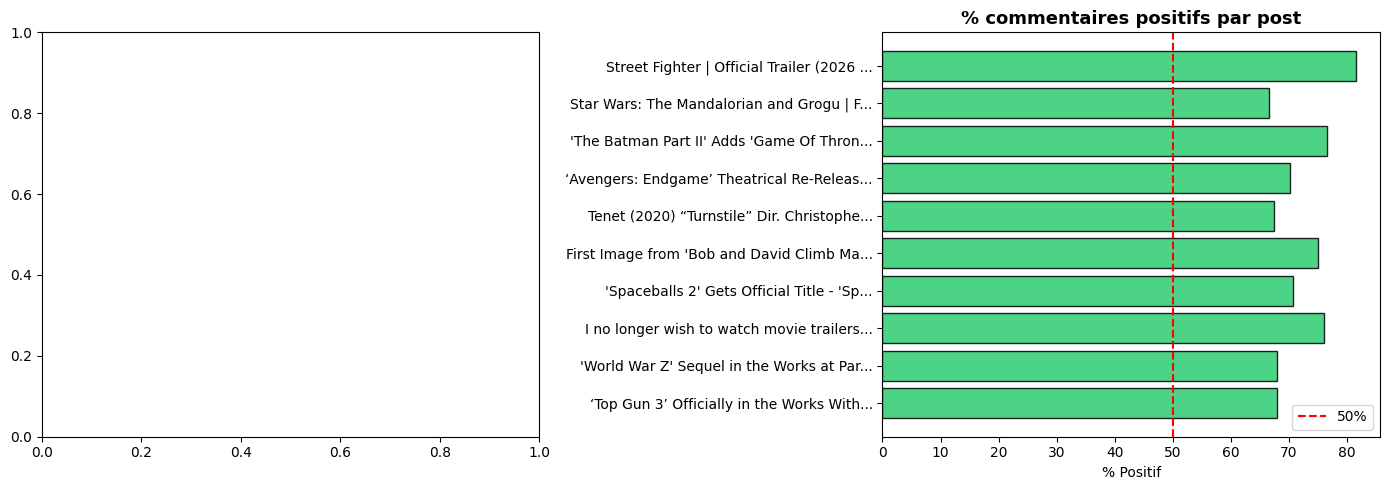

In [38]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# Top 10 posts par nb de commentaires + leur sentiment
top_posts = df_reddit.groupby('post_title').agg(
    total     = ('sentiment_label', 'count'),
    positifs  = ('sentiment_label', lambda x: (x == 'Positif').sum()),
    negatifs  = ('sentiment_label', lambda x: (x == 'Négatif').sum()),
).sort_values('total', ascending=False).head(10)


top_posts['ratio_positif'] = (top_posts['positifs'] / top_posts['total'] * 100).round(1)
print("\n=== TOP 10 POSTS ===")
print(top_posts)

# Barplot ratio positif par post
short_titles = [t[:40] + '...' for t in top_posts.index]
axes[1].barh(short_titles[::-1], top_posts['ratio_positif'][::-1],
             color='#2ecc71', edgecolor='black', alpha=0.85)
axes[1].axvline(x=50, color='red', linestyle='--', label='50%')
axes[1].set_title('% commentaires positifs par post', fontsize=13, fontweight='bold')
axes[1].set_xlabel('% Positif')
axes[1].legend()

plt.tight_layout()
plt.savefig('analyse_reddit.png', dpi=150, bbox_inches='tight')
plt.show()

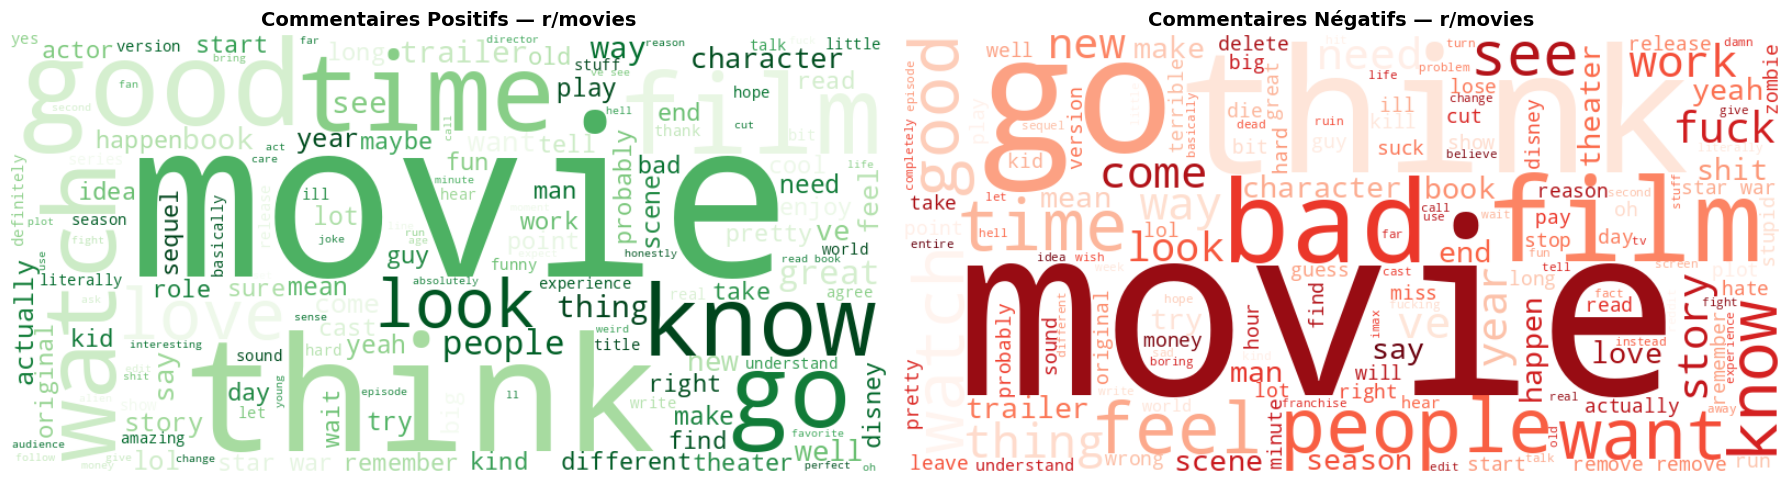

In [39]:
# Sépare les commentaires positifs et négatifs
positifs = ' '.join(df_reddit[df_reddit['sentiment_label'] == 'Positif']['comment_nlp'].astype(str))
negatifs = ' '.join(df_reddit[df_reddit['sentiment_label'] == 'Négatif']['comment_nlp'].astype(str))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Word Cloud Positif
wc_pos = WordCloud(width=800, height=400, max_words=150,
                   background_color='white', colormap='Greens').generate(positifs)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Commentaires Positifs — r/movies', fontsize=14, fontweight='bold')

# Word Cloud Négatif
wc_neg = WordCloud(width=800, height=400, max_words=150,
                   background_color='white', colormap='Reds').generate(negatifs)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Commentaires Négatifs — r/movies', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

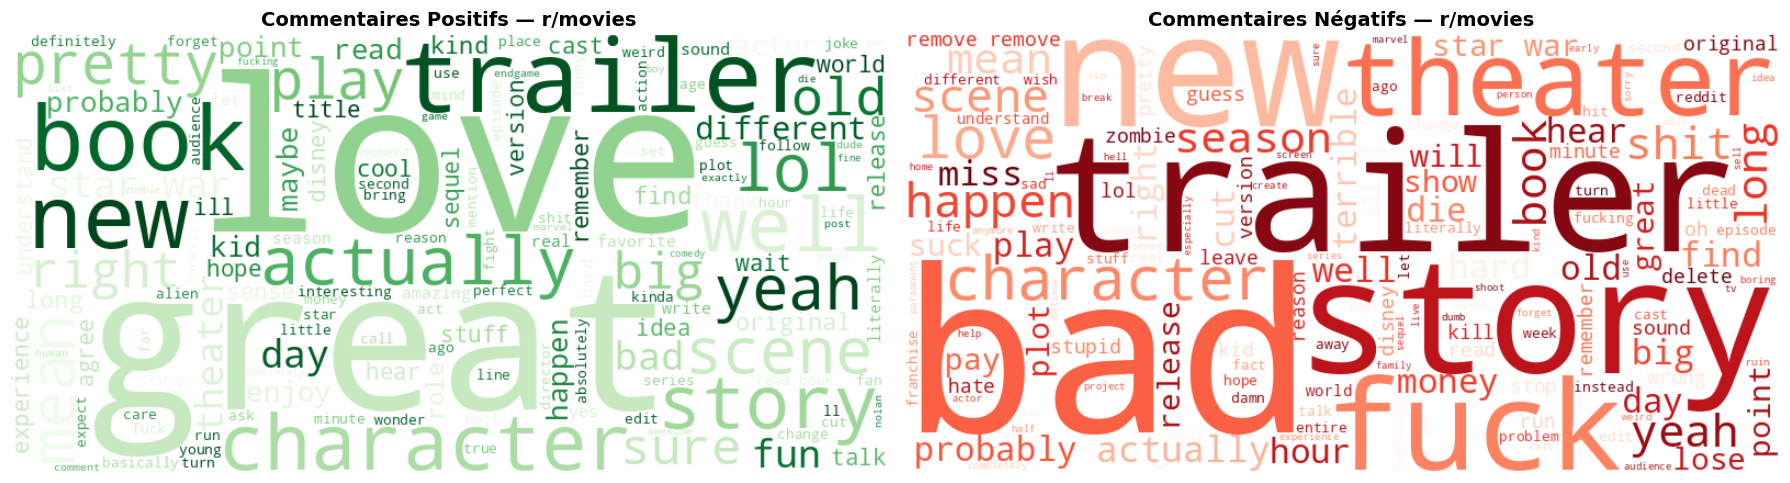

In [40]:
# Mots trop génériques à exclure
custom_stopwords = {
    'movie', 'film', 'think', 'go', 'know', 'want', 'say', 'make',
    'good', 'people', 'work', 'time', 'way', 'thing', 'look', 'come',
    'watch', 'see', 'feel', 'need', 'take', 'give', 'tell', 'try',
    'year', 'lot', 'bit', 'guy', 'man', 'end', 'start', 'like', 'get', 've'
}

def remove_custom_stopwords(text):
    return ' '.join([w for w in text.split() if w not in custom_stopwords])

positifs_filtered = remove_custom_stopwords(positifs)
negatifs_filtered = remove_custom_stopwords(negatifs)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

wc_pos = WordCloud(width=800, height=400, max_words=150,
                   background_color='white', colormap='Greens').generate(positifs_filtered)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Commentaires Positifs — r/movies', fontsize=14, fontweight='bold')

wc_neg = WordCloud(width=800, height=400, max_words=150,
                   background_color='white', colormap='Reds').generate(negatifs_filtered)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Commentaires Négatifs — r/movies', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Sans NLP

In [8]:
with open('../../notebook/entrainement/vectorizer_final.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

E0000 00:00:1776587460.911710    7786 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [9]:
model = load_model("../../model/keras/Final.keras")

In [11]:
X_reddit = vectorizer(df_reddit['comment_clean'].values)
predictions = model.predict(X_reddit)

387/387 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step


In [13]:
df_reddit['score_sentiment'] = predictions
df_reddit['sentiment']       = (predictions > 0.5).astype(int)
df_reddit['sentiment_label'] = df_reddit['sentiment'].map({0: 'Négatif', 1: 'Positif'})

In [14]:
# Analyse des tendances
print("=== TENDANCES GLOBALES ===")
print(df_reddit['sentiment_label'].value_counts())
print()
print(df_reddit['sentiment_label'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

=== TENDANCES GLOBALES ===
sentiment_label
Positif    6995
Négatif    5378
Name: count, dtype: int64

sentiment_label
Positif    56.5%
Négatif    43.5%
Name: proportion, dtype: str


In [15]:
df_reddit.to_csv("predict_reddit_sans_nlp_model_final.csv")

In [16]:
df_reddit

,post_title,comment,score,date,comment_clean,score_sentiment,sentiment,sentiment_label
0,AMA/Q&A Announcement - Fisher Stevens - Friday...,"Fisher Stevens, actor & filmmaker, will be joi...",1,1.776444e+09,fisher stevens actor filmmaker will be joining...,0.531762,1,Positif
1,AMA/Q&A Announcement - Fisher Stevens - Friday...,Don't forget Hackers!\n\nHack the planet!,390,1.776444e+09,dont forget hackers hack the planet,0.901421,1,Positif
2,AMA/Q&A Announcement - Fisher Stevens - Friday...,Did you ever fix that review of Paddy's Pub?,179,1.776445e+09,did you ever fix that review of paddys pub,0.720636,1,Positif
3,AMA/Q&A Announcement - Fisher Stevens - Friday...,Does anyone at all happen to be old enough to ...,77,1.776446e+09,does anyone at all happen to be old enough to ...,0.126635,0,Négatif
4,AMA/Q&A Announcement - Fisher Stevens - Friday...,Mr. The Plague!,67,1.776444e+09,mr the plague,0.106745,0,Négatif
...,...,...,...,...,...,...,...,...
12368,'Spaceballs 2' Gets Official Title - 'Spacebal...,don’t bother,1,1.776351e+09,dont bother,0.556203,1,Positif
12369,'Spaceballs 2' Gets Official Title - 'Spacebal...,"I hate to be that guy, but it would be 4 1/2",6,1.776352e+09,i hate to be that guy but it would be,0.181672,0,Négatif
12370,'Spaceballs 2' Gets Official Title - 'Spacebal...,It looks to me like I’ve got all the Schwartze...,6,1.776339e+09,it looks to me like ive got all the schwartzes,0.230221,0,Négatif
12371,'Spaceballs 2' Gets Official Title - 'Spacebal...,Actually now that I think about it it would be...,11,1.776353e+09,actually now that i think about it it would be...,0.480715,0,Négatif


# Comparatifs 

In [18]:
df_sans = pd.read_csv('predict_reddit_sans_nlp_model_final.csv')
df_nlp  = pd.read_csv('clean_nlp_comment_reddi_final_predict.csv')

print(f"Sans NLP : {len(df_sans)} lignes | Avec NLP : {len(df_nlp)} lignes")

Sans NLP : 12373 lignes | Avec NLP : 12233 lignes


In [19]:
print("=" * 55)
print("        COMPARAISON DES DEUX TRAITEMENTS")
print("=" * 55)

for label, df in [("SANS NLP (clean classique)", df_sans), ("AVEC NLP (lemmatization+stopwords)", df_nlp)]:
    pos = (df['sentiment_label'] == 'Positif').sum()
    neg = (df['sentiment_label'] == 'Négatif').sum()
    total = len(df)
    print(f"\n>>> {label}")
    print(f"  Total commentaires              : {total}")
    print(f"  Positifs                        : {pos} ({pos/total*100:.1f}%)")
    print(f"  Négatifs                        : {neg} ({neg/total*100:.1f}%)")
    print(f"  Score moyen                     : {df['score_sentiment'].mean():.4f}")
    print(f"  Score médian                    : {df['score_sentiment'].median():.4f}")
    print(f"  Ecart-type                      : {df['score_sentiment'].std():.4f}")
    print(f"  Scores > 0.8 (très confiant +)  : {(df['score_sentiment'] > 0.8).sum()} ({(df['score_sentiment'] > 0.8).mean()*100:.1f}%)")
    print(f"  Scores < 0.2 (très confiant -)  : {(df['score_sentiment'] < 0.2).sum()} ({(df['score_sentiment'] < 0.2).mean()*100:.1f}%)")

        COMPARAISON DES DEUX TRAITEMENTS

>>> SANS NLP (clean classique)
  Total commentaires              : 12373
  Positifs                        : 6995 (56.5%)
  Négatifs                        : 5378 (43.5%)
  Score moyen                     : 0.5436
  Score médian                    : 0.5669
  Ecart-type                      : 0.2802
  Scores > 0.8 (très confiant +)  : 2941 (23.8%)
  Scores < 0.2 (très confiant -)  : 1863 (15.1%)

>>> AVEC NLP (lemmatization+stopwords)
  Total commentaires              : 12233
  Positifs                        : 8674 (70.9%)
  Négatifs                        : 3559 (29.1%)
  Score moyen                     : 0.6477
  Score médian                    : 0.7058
  Ecart-type                      : 0.2747
  Scores > 0.8 (très confiant +)  : 4646 (38.0%)
  Scores < 0.2 (très confiant -)  : 1101 (9.0%)


In [20]:
incertains_sans = df_sans[(df_sans['score_sentiment'] > 0.4) & (df_sans['score_sentiment'] < 0.6)]
incertains_nlp  = df_nlp[(df_nlp['score_sentiment'] > 0.4)  & (df_nlp['score_sentiment'] < 0.6)]

print(f"Prédictions INCERTAINES (score entre 0.4 et 0.6):")
print(f"  Sans NLP : {len(incertains_sans)} ({len(incertains_sans)/len(df_sans)*100:.1f}%)")
print(f"  Avec NLP : {len(incertains_nlp)} ({len(incertains_nlp)/len(df_nlp)*100:.1f}%)")

print(f"\nParmi les incertains, combien classés Positif ?")
print(f"  Sans NLP : {(incertains_sans['sentiment_label']=='Positif').sum()} / {len(incertains_sans)}")
print(f"  Avec NLP : {(incertains_nlp['sentiment_label']=='Positif').sum()} / {len(incertains_nlp)}")

Prédictions INCERTAINES (score entre 0.4 et 0.6):
  Sans NLP : 2505 (20.2%)
  Avec NLP : 2094 (17.1%)

Parmi les incertains, combien classés Positif ?
  Sans NLP : 1379 / 2505
  Avec NLP : 1190 / 2094


In [21]:
merged = pd.merge(
    df_sans[['comment', 'comment_clean', 'score_sentiment', 'sentiment_label']],
    df_nlp[['comment', 'comment_nlp', 'score_sentiment', 'sentiment_label']],
    on='comment',
    suffixes=('_sans', '_nlp')
)

merged['diff_score'] = merged['score_sentiment_nlp'] - merged['score_sentiment_sans']
merged['accord'] = merged['sentiment_label_sans'] == merged['sentiment_label_nlp']

print(f"Commentaires en commun : {len(merged)}")
print(f"Accord sur le label    : {merged['accord'].sum()} ({merged['accord'].mean()*100:.1f}%)")
print(f"Désaccord              : {(~merged['accord']).sum()} ({(~merged['accord']).mean()*100:.1f}%)")
print(f"Diff score moyenne (NLP - Sans) : {merged['diff_score'].mean():+.4f}")
print(f"\nRépartition des changements de label :")
print(merged.groupby(['sentiment_label_sans', 'sentiment_label_nlp']).size())

Commentaires en commun : 25313
Accord sur le label    : 22280 (88.0%)
Désaccord              : 3033 (12.0%)
Diff score moyenne (NLP - Sans) : +0.2029

Répartition des changements de label :
sentiment_label_sans  sentiment_label_nlp
Négatif               Négatif                15919
                      Positif                 2403
Positif               Négatif                  630
                      Positif                 6361
dtype: int64


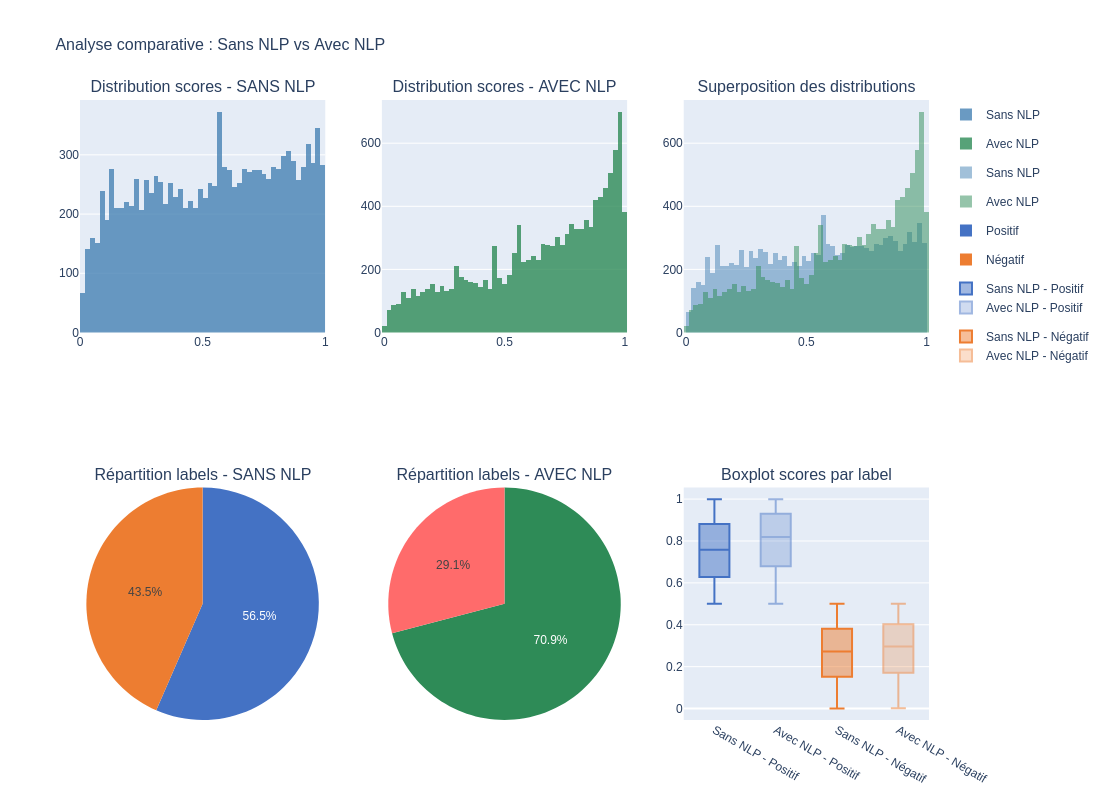

In [22]:
fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=(
        'Distribution scores - SANS NLP',
        'Distribution scores - AVEC NLP',
        'Superposition des distributions',
        'Répartition labels - SANS NLP',
        'Répartition labels - AVEC NLP',
        'Boxplot scores par label'
    ),
    specs=[
        [{"type": "histogram"}, {"type": "histogram"}, {"type": "histogram"}],
        [{"type": "pie"},       {"type": "pie"},       {"type": "box"}]
    ]
)

# 1. Histogram sans NLP
fig.add_trace(go.Histogram(
    x=df_sans['score_sentiment'], nbinsx=50,
    name='Sans NLP', marker_color='steelblue', opacity=0.8
), row=1, col=1)

# 2. Histogram avec NLP
fig.add_trace(go.Histogram(
    x=df_nlp['score_sentiment'], nbinsx=50,
    name='Avec NLP', marker_color='seagreen', opacity=0.8
), row=1, col=2)

# 3. Superposition
fig.add_trace(go.Histogram(
    x=df_sans['score_sentiment'], nbinsx=50,
    name='Sans NLP', marker_color='steelblue', opacity=0.5
), row=1, col=3)
fig.add_trace(go.Histogram(
    x=df_nlp['score_sentiment'], nbinsx=50,
    name='Avec NLP', marker_color='seagreen', opacity=0.5
), row=1, col=3)

# 4. Pie SANS NLP
counts_sans = df_sans['sentiment_label'].value_counts()
fig.add_trace(go.Pie(
    labels=counts_sans.index, values=counts_sans.values,
    name='Sans NLP', marker_colors=['#4472C4', '#ED7D31']
), row=2, col=1)

# 5. Pie AVEC NLP
counts_nlp = df_nlp['sentiment_label'].value_counts()
fig.add_trace(go.Pie(
    labels=counts_nlp.index, values=counts_nlp.values,
    name='Avec NLP', marker_colors=['#2E8B57', '#FF6B6B']
), row=2, col=2)

# 6. Boxplot
for label, color in [('Positif', '#4472C4'), ('Négatif', '#ED7D31')]:
    fig.add_trace(go.Box(
        y=df_sans[df_sans['sentiment_label']==label]['score_sentiment'],
        name=f'Sans NLP - {label}', marker_color=color, legendgroup=label
    ), row=2, col=3)
    fig.add_trace(go.Box(
        y=df_nlp[df_nlp['sentiment_label']==label]['score_sentiment'],
        name=f'Avec NLP - {label}', marker_color=color, opacity=0.5, legendgroup=label
    ), row=2, col=3)

fig.update_layout(
    height=800, title_text="Analyse comparative : Sans NLP vs Avec NLP",
    title_font_size=16, barmode='overlay', showlegend=True
)
fig.show()

In [23]:
desaccord_pos_neg = merged[(merged['sentiment_label_sans']=='Positif') & (merged['sentiment_label_nlp']=='Négatif')]
desaccord_neg_pos = merged[(merged['sentiment_label_sans']=='Négatif') & (merged['sentiment_label_nlp']=='Positif')]

print(f"Sans NLP=Positif → Avec NLP=Négatif : {len(desaccord_pos_neg)} cas")
print(f"Sans NLP=Négatif → Avec NLP=Positif : {len(desaccord_neg_pos)} cas\n")

print("=" * 60)
print("Exemples Sans NLP=Positif → Avec NLP=Négatif")
print("(stopwords ont retiré des négations → perd le négatif)")
print("=" * 60)
for _, row in desaccord_pos_neg.head(5).iterrows():
    print(f"\n📝 {str(row['comment'])[:120]}...")
    print(f"   clean simple : {str(row['comment_clean'])[:100]}")
    print(f"   clean NLP    : {str(row['comment_nlp'])[:100]}")
    print(f"   Score SANS: {row['score_sentiment_sans']:.3f} → {row['sentiment_label_sans']}")
    print(f"   Score NLP : {row['score_sentiment_nlp']:.3f} → {row['sentiment_label_nlp']}")

print("\n" + "=" * 60)
print("Exemples Sans NLP=Négatif → Avec NLP=Positif")
print("=" * 60)
for _, row in desaccord_neg_pos.head(5).iterrows():
    print(f"\n📝 {str(row['comment'])[:120]}...")
    print(f"   clean simple : {str(row['comment_clean'])[:100]}")
    print(f"   clean NLP    : {str(row['comment_nlp'])[:100]}")
    print(f"   Score SANS: {row['score_sentiment_sans']:.3f} → {row['sentiment_label_sans']}")
    print(f"   Score NLP : {row['score_sentiment_nlp']:.3f} → {row['sentiment_label_nlp']}")

Sans NLP=Positif → Avec NLP=Négatif : 630 cas
Sans NLP=Négatif → Avec NLP=Positif : 2403 cas

Exemples Sans NLP=Positif → Avec NLP=Négatif
(stopwords ont retiré des négations → perd le négatif)

📝 Amazing in LOST! Heavily featured in the best TV ep of the century The Constant...
   clean simple : amazing in lost heavily featured in the best tv ep of the century the constant
   clean NLP    : amazing lose heavily feature good tv ep century constant
   Score SANS: 0.678 → Positif
   Score NLP : 0.287 → Négatif

📝 HACK THE PLANETT!!!!...
   clean simple : hack the planett
   clean NLP    : hack planett
   Score SANS: 0.528 → Positif
   Score NLP : 0.360 → Négatif

📝 HACK THE PLANET!...
   clean simple : hack the planet
   clean NLP    : hack planet
   Score SANS: 0.632 → Positif
   Score NLP : 0.484 → Négatif

📝 Hack the planet!...
   clean simple : hack the planet
   clean NLP    : hack planet
   Score SANS: 0.632 → Positif
   Score NLP : 0.484 → Négatif

📝 HACK THE PLANET!!!!!!!!...
   

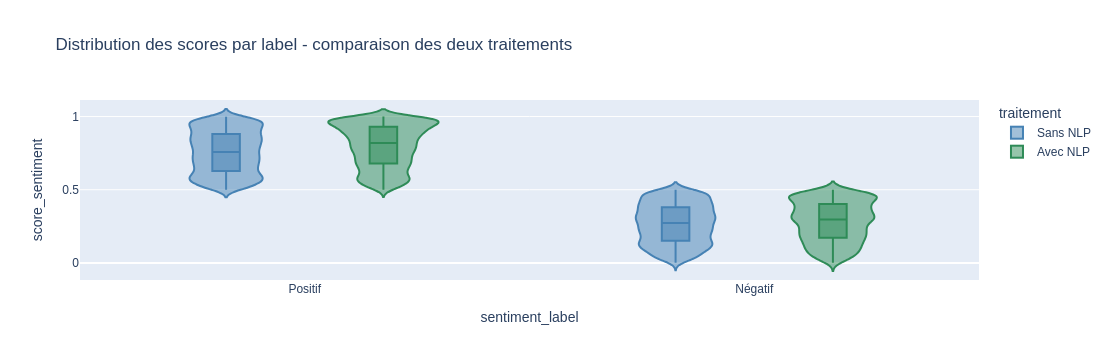

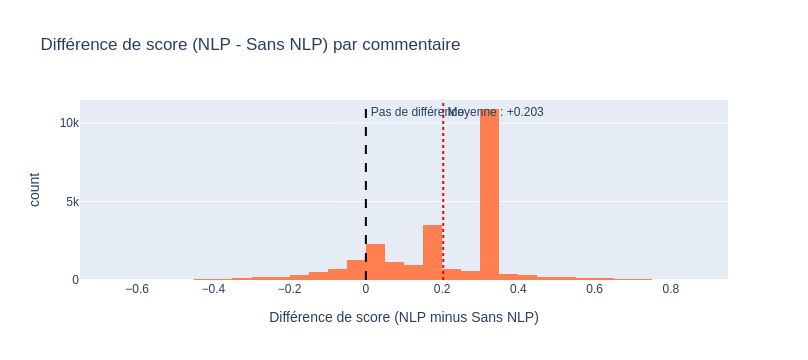

In [24]:
# Violin plot : distribution des scores par label et traitement
data_violin = pd.concat([
    df_sans[['score_sentiment','sentiment_label']].assign(traitement='Sans NLP'),
    df_nlp[['score_sentiment','sentiment_label']].assign(traitement='Avec NLP')
])

fig2 = px.violin(
    data_violin, x='sentiment_label', y='score_sentiment',
    color='traitement', box=True, points=False,
    color_discrete_map={'Sans NLP':'steelblue', 'Avec NLP':'seagreen'},
    title="Distribution des scores par label - comparaison des deux traitements"
)
fig2.show()

# Scatter : différence de score pour chaque commentaire commun
fig3 = px.histogram(
    merged, x='diff_score', nbins=80,
    color_discrete_sequence=['coral'],
    title="Différence de score (NLP - Sans NLP) par commentaire",
    labels={'diff_score': 'Différence de score (NLP minus Sans NLP)'}
)
fig3.add_vline(x=0, line_dash="dash", line_color="black", annotation_text="Pas de différence")
fig3.add_vline(x=merged['diff_score'].mean(), line_dash="dot", line_color="red",
               annotation_text=f"Moyenne : {merged['diff_score'].mean():+.3f}")
fig3.show()